# Projeto Final
This notebook downloads the BraTS 2018 and 2020 datasets from Kaggle. Make sure you have accepted the competition rules on Kaggle for these datasets.

## Download dos Datasets

In [1]:
import os
from google.colab import userdata

# Securely retrieve Kaggle credentials from Colab Secrets
try:
    os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
    os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')
except Exception as e:
    print("Please add KAGGLE_USERNAME and KAGGLE_KEY to your Colab Secrets.")

# Create directory for datasets
!mkdir -p datasets/brats2018 datasets/brats2020

In [2]:
import os
import glob

def baixar_e_limpar(slug_dataset, diretorio_destino):
    """Baixa um dataset do Kaggle e remove o arquivo zip para economizar espaço."""
    print(f"\n--- Processando {slug_dataset} ---")

    # 1. Download
    !kaggle datasets download -d {slug_dataset} -p {diretorio_destino}

    # 2. Extração
    arquivos_zip = glob.glob(os.path.join(diretorio_destino, "*.zip"))
    if arquivos_zip:
        for caminho_zip in arquivos_zip:
            print(f"Extraindo {caminho_zip}...")
            !unzip -q {caminho_zip} -d {diretorio_destino}
            # 3. Limpeza do zip para economizar espaço em disco
            os.remove(caminho_zip)
            print(f"Removido {caminho_zip} para liberar espaço.")
    else:
        print(f"Nenhum arquivo zip encontrado em {diretorio_destino} (pode já estar extraído).")

# Configuração
BRATS_2018 = "sanglequang/brats2018"
BRATS_2020 = "awsaf49/brats20-dataset-training-validation"

# Execução
if not os.path.exists('datasets/brats2018/MICCAI_BraTS_2018_Data_Training'):
    baixar_e_limpar(BRATS_2018, 'datasets/brats2018')
else:
    print("BraTS 2018 já existe e está extraído.")

if not os.path.exists('datasets/brats2020/BraTS2020_TrainingData'):
    baixar_e_limpar(BRATS_2020, 'datasets/brats2020')
else:
    print("BraTS 2020 já existe e está extraído.")

print("\n Todos os datasets foram processados e limpos.")


--- Processando sanglequang/brats2018 ---
Dataset URL: https://www.kaggle.com/datasets/sanglequang/brats2018
License(s): unknown
100% 3.18G/3.18G [00:30<00:00, 110MB/s] 

Extraindo datasets/brats2018/brats2018.zip...
Removido datasets/brats2018/brats2018.zip para liberar espaço.

--- Processando awsaf49/brats20-dataset-training-validation ---
Dataset URL: https://www.kaggle.com/datasets/awsaf49/brats20-dataset-training-validation
License(s): CC0-1.0
100% 4.16G/4.16G [00:33<00:00, 133MB/s] 

Extraindo datasets/brats2020/brats20-dataset-training-validation.zip...
Removido datasets/brats2020/brats20-dataset-training-validation.zip para liberar espaço.

 Todos os datasets foram processados e limpos.


## Entendendo o Formato e Modalidades


### Tarefa
Explorar os fundamentos do conjunto de dados BraTS (Brain Tumor Segmentation) analisando o formato de arquivo NIfTI (.nii) e as quatro modalidades de ressonância magnética (T1, T1ce, T2, FLAIR) localizadas em “datasets/brats2018” e “datasets/brats2020”, definir o significado biológico dos rótulos de segmentação (Núcleo do tumor, Tumor com realce e Tumor completo) e investigar técnicas essenciais de pré-processamento de imagens médicas 3D, como normalização por Z-score e correção de campo de desvio, para se preparar para a implementação de uma arquitetura 3D U-Net.
### Ideia:
Explorar o que são arquivos .nii (NIfTI) e por que o BRaTS utiliza quatro modalidades de RM (T1, T1ce, T2, FLAIR).

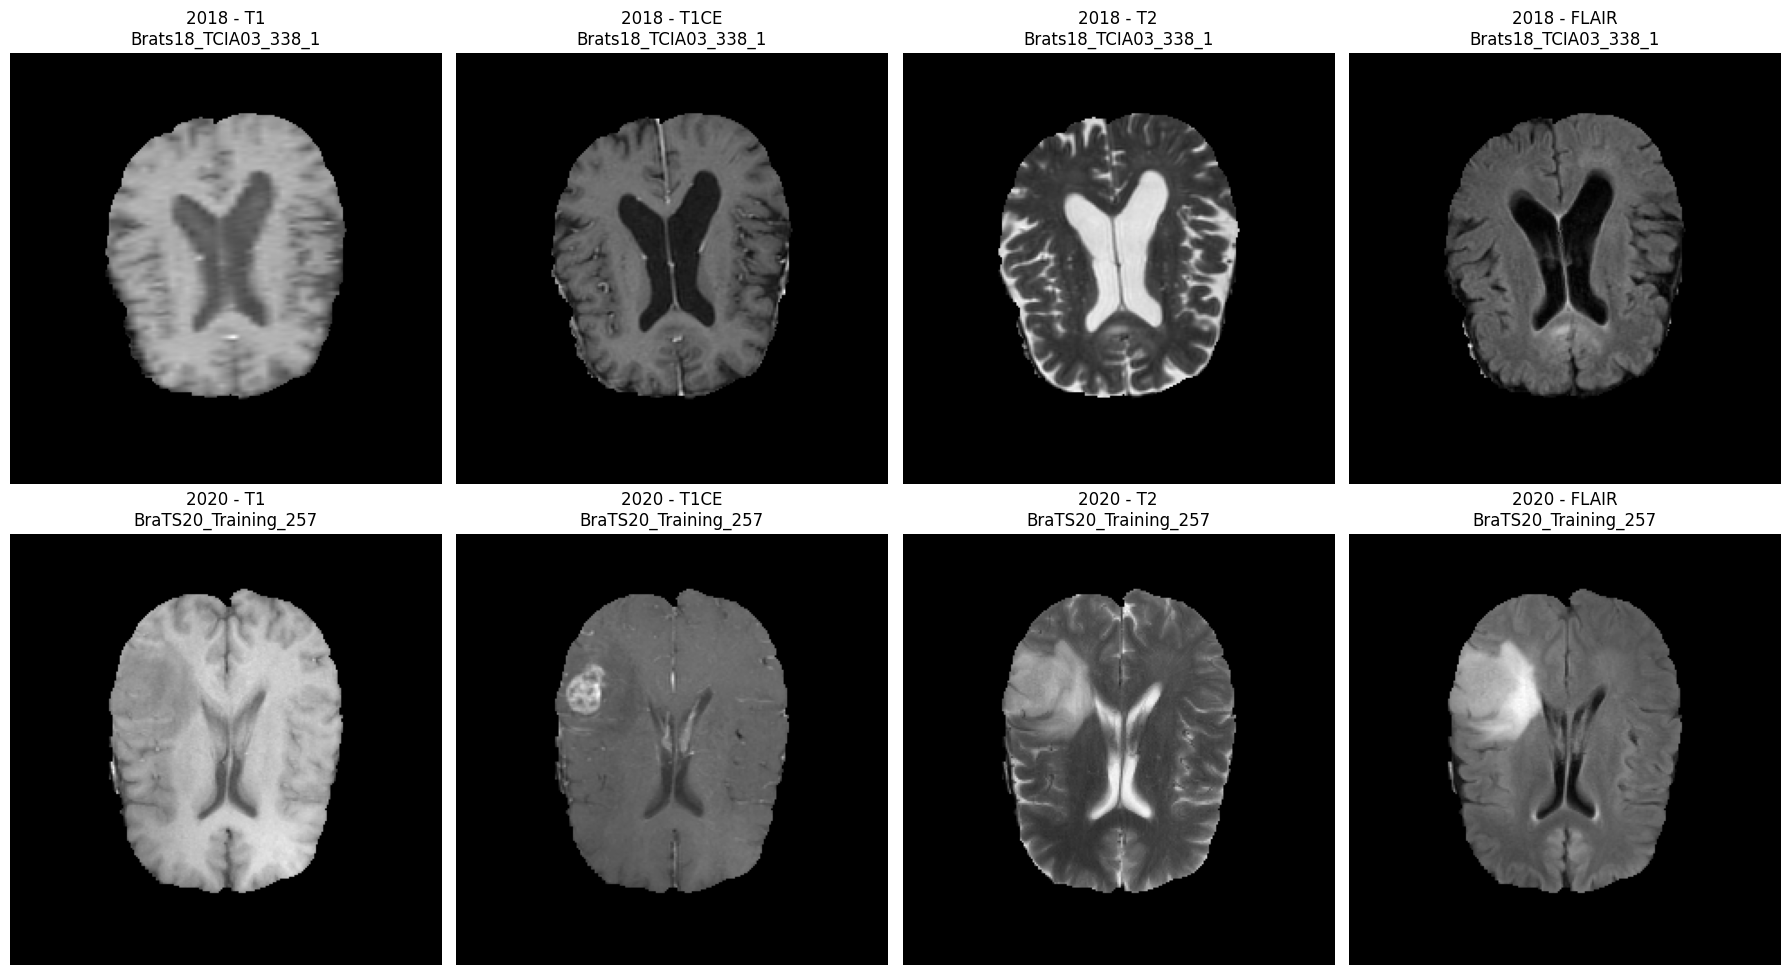

In [ ]:
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np
import glob
import os

# Configuração de Caminhos
diretorio_2018 = 'datasets/brats2018/MICCAI_BraTS_2018_Data_Training/HGG'
pastas_2018 = sorted(glob.glob(os.path.join(diretorio_2018, 'Brats18_*')))

diretorio_2020 = 'datasets/brats2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData'
pastas_2020 = sorted(glob.glob(os.path.join(diretorio_2020, 'BraTS20_Training_*')))

def carregar_modalidades(pasta_paciente):
    modalidades = ['t1', 't1ce', 't2', 'flair']
    dados_paciente = {}
    for m in modalidades:
        arquivos = glob.glob(os.path.join(pasta_paciente, f'*{m}.nii*'))
        if arquivos:
            img = nib.load(arquivos[0])
            fatia = img.get_fdata()[:, :, img.shape[2] // 2]
            dados_paciente[m] = np.rot90(fatia)
    return dados_paciente

if pastas_2018 and pastas_2020:
    paciente_18 = np.random.choice(pastas_2018)
    paciente_20 = np.random.choice(pastas_2020)

    imgs_18 = carregar_modalidades(paciente_18)
    imgs_20 = carregar_modalidades(paciente_20)

    # --- Visualização ---
    fig, eixos = plt.subplots(2, 4, figsize=(18, 10))
    modalidades = ['t1', 't1ce', 't2', 'flair']

    for i, m in enumerate(modalidades):
        # Linha 1: BraTS 2018
        if m in imgs_18:
            eixos[0, i].imshow(imgs_18[m], cmap='gray')
            eixos[0, i].set_title(f"2018 - {m.upper()}\n{os.path.basename(paciente_18)}")
            eixos[0, i].axis('off')

        # Linha 2: BraTS 2020
        if m in imgs_20:
            eixos[1, i].imshow(imgs_20[m], cmap='gray')
            eixos[1, i].set_title(f"2020 - {m.upper()}\n{os.path.basename(paciente_20)}")
            eixos[1, i].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Erro ao localizar as pastas. Verifique os caminhos dos datasets.")

### Inspeção de Dimensões e Voxels
Nesta etapa, vamos verificar como o Python enxerga os volumes 3D.
- **Shape**: Indica (Altura, Largura, Profundidade, Modalidades).
- **Voxels**: São os equivalentes 3D dos pixels.

In [ ]:
import nibabel as nib
import glob
import os
import numpy as np

# Verificandteados no bloco anterior existem no ambienteo se os pacientes sor
if 'paciente_18' in locals() and 'paciente_20' in locals():
    pacientes_para_inspecao = [('2018', paciente_18), ('2020', paciente_20)]

    for ano, caminho in pacientes_para_inspecao:
        print(f"=== Analisando BraTS {ano}: {os.path.basename(caminho)} ===\n")

        modalidades = ['t1', 't1ce', 't2', 'flair', 'seg']

        for m in modalidades:
            arquivos = glob.glob(os.path.join(caminho, f'*{m}.nii*'))
            if arquivos:
                img = nib.load(arquivos[0])
                dados = img.get_fdata()

                print(f"Modalidade: {m.upper()}")
                print(f"  - Shape (H, W, D): {dados.shape}")
                print(f"  - Intensidade Mínima: {np.min(dados):.1f}")
                print(f"  - Intensidade Máxima: {np.max(dados):.1f}")
                print(f"  - Média de Intensidade: {np.mean(dados):.1f}")
                print(f"  - Desvio Padrão de Intensidade: {np.std(dados):.1f}")

                if m == 'seg':
                    print(f"  - Labels únicos: {np.unique(dados)}")
                print("-" * 30)
        print("\n" + "="*50 + "\n")
else:
    print("Erro: Execute o bloco de visualização acima primeiro para sortear os pacientes.")

=== Analisando BraTS 2018: Brats18_TCIA03_338_1 ===

Modalidade: T1
  - Shape (H, W, D): (240, 240, 155)
  - Intensidade Mínima: 0.0
  - Intensidade Máxima: 823.0
  - Média de Intensidade: 35.6
  - Desvio Padrão de Intensidade: 82.7
------------------------------
Modalidade: T1CE
  - Shape (H, W, D): (240, 240, 155)
  - Intensidade Mínima: 0.0
  - Intensidade Máxima: 290.0
  - Média de Intensidade: 10.9
  - Desvio Padrão de Intensidade: 26.0
------------------------------
Modalidade: T2
  - Shape (H, W, D): (240, 240, 155)
  - Intensidade Mínima: 0.0
  - Intensidade Máxima: 763.0
  - Média de Intensidade: 42.4
  - Desvio Padrão de Intensidade: 112.5
------------------------------
Modalidade: FLAIR
  - Shape (H, W, D): (240, 240, 155)
  - Intensidade Mínima: 0.0
  - Intensidade Máxima: 449.0
  - Média de Intensidade: 18.1
  - Desvio Padrão de Intensidade: 44.4
------------------------------
Modalidade: SEG
  - Shape (H, W, D): (240, 240, 155)
  - Intensidade Mínima: 0.0
  - Intensidade 

## Préprocessamento


### Correção de Iluminação de Fundo (N4 Bias Field Correction) OPCIONAL
**Objetivo:** Remover gradientes artificiais de intensidade causados por imperfeições no campo magnético do aparelho de ressonância no momento do exame.
**Justificativa Analítica:** Imperfeições no campo magnético geram artefatos onde um hemisfério do cérebro aparece artificialmente mais claro que o outro. Redes neurais podem aprender esses gradientes erradamente. O algoritmo N4 estima e subtrai esse campo de viés, homogeneizando o tecido. Aplicaremos isso na modalidade T1 do paciente de 2020.
*(Nota: Instalar biblioteca executando `!pip install SimpleITK` na célula anterior se necessário)*

In [ ]:
!pip install SimpleITK

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 6.4 MB/s eta 0:00:00


Aplicando N4 Bias Correction no paciente BraTS20_Training_257...
Isto pode demorar cerca de 10 a 30 segundos dependendo da CPU do Colab.


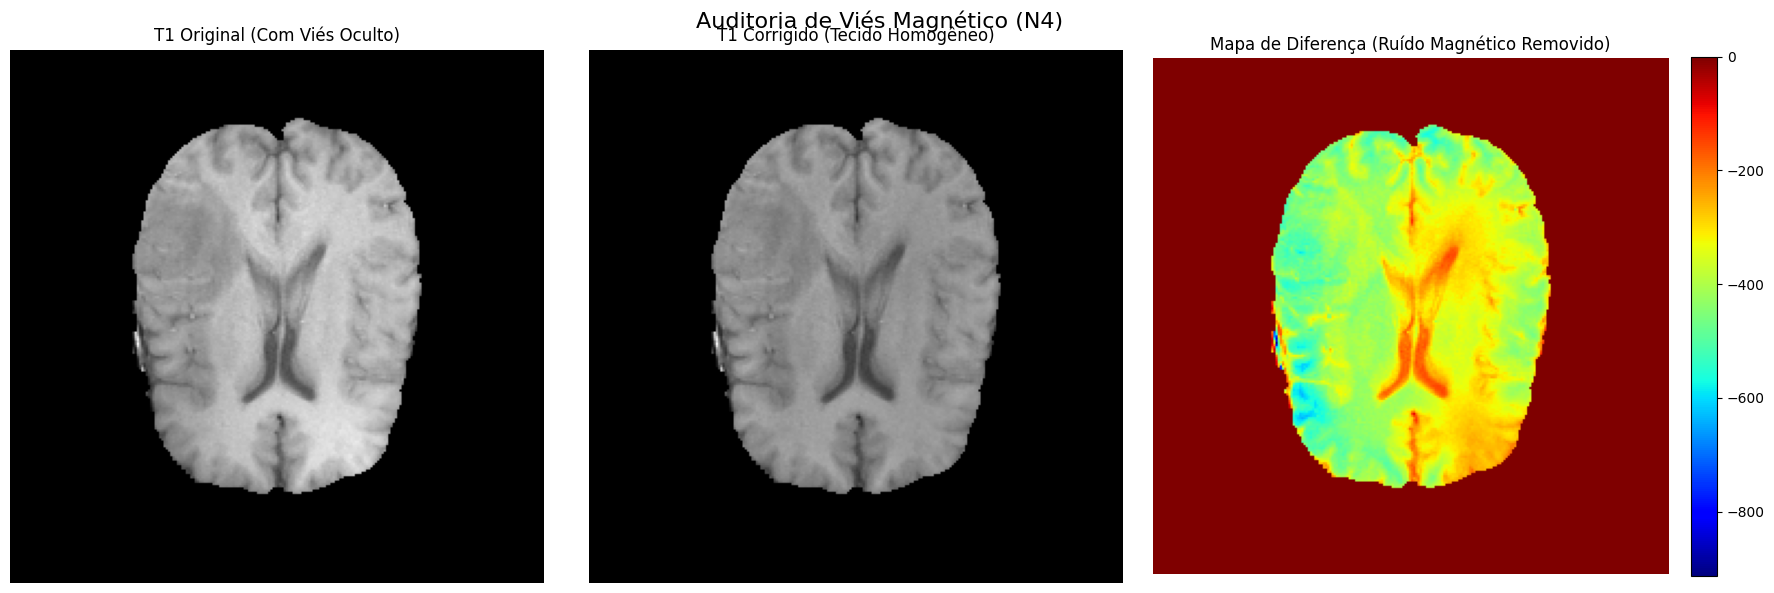

In [ ]:
import SimpleITK as sitk

# Carregando o volume 3D INTEIRO do T1 do paciente BraTS 2020
arquivo_t1 = glob.glob(os.path.join(paciente_20, '*t1.nii*'))[0]
volume_t1_bruto = nib.load(arquivo_t1).get_fdata()

def aplicar_correcao_n4(volume_numpy):
    # O SimpleITK trabalha com o seu próprio formato de imagem
    sitk_image = sitk.GetImageFromArray(volume_numpy.astype(np.float32))

    # Criar uma máscara para focar o cálculo do N4 apenas no cérebro (otimiza o tempo computacional)
    mask_image = sitk.OtsuThreshold(sitk_image, 0, 1, 200)

    # Aplicar o Filtro N4
    n4_filter = sitk.N4BiasFieldCorrectionImageFilter()
    corrected_image = n4_filter.Execute(sitk_image, mask_image)

    return sitk.GetArrayFromImage(corrected_image)

def aplicar_n4_otimizado(volume_numpy):
    """
    Versão otimizada do N4: Encolhe a imagem em 4x para calcular o viés magnético,
    derrubando o tempo de processamento de minutos para segundos.
    """
    # 1. Converter para SimpleITK
    sitk_image = sitk.GetImageFromArray(volume_numpy.astype(np.float32))

    # 2. Criar a máscara na imagem original
    mask_image = sitk.OtsuThreshold(sitk_image, 0, 1, 200)

    # 3. O SEGREDO: Encolher a imagem e a máscara em 4x (fator 4)
    shrink_factor = 4
    shrunk_image = sitk.Shrink(sitk_image, [shrink_factor]*sitk_image.GetDimension())
    shrunk_mask = sitk.Shrink(mask_image, [shrink_factor]*sitk_image.GetDimension())

    # 4. Calcular o N4 na imagem PEQUENA
    n4_filter = sitk.N4BiasFieldCorrectionImageFilter()
    # Retorna a imagem pequena corrigida (mas não a queremos, queremos o campo gerado)
    n4_filter.Execute(shrunk_image, shrunk_mask)

    # 5. Extrair o campo de log-bias calculado e aplicar na imagem de tamanho ORIGINAL
    log_bias_field = n4_filter.GetLogBiasFieldAsImage(sitk_image)

    # A matemática reversa do N4: Imagem Corrigida = Imagem Original / exp(LogBias)
    corrected_image_sitk = sitk_image / sitk.Exp(log_bias_field)

    return sitk.GetArrayFromImage(corrected_image_sitk)

print(f"Aplicando N4 Bias Correction no paciente {os.path.basename(paciente_20)}...")
print("Isto pode demorar cerca de 10 a 30 segundos dependendo da CPU do Colab.")
volume_t1_corrigido = aplicar_n4_otimizado(volume_t1_bruto)

# --- Visualização Analítica (Fatia Central vs. Fatia Corrigida vs. Mapa de Viés) ---
fatia_z = volume_t1_bruto.shape[2] // 2
img_original = np.rot90(volume_t1_bruto[:, :, fatia_z])
img_corrigida = np.rot90(volume_t1_corrigido[:, :, fatia_z])

# Subtrair a imagem corrigida da original revela o campo magnético irregular que estava oculto
mapa_diferenca = img_original - img_corrigida

fig, eixos = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Auditoria de Viés Magnético (N4)", fontsize=16)

eixos[0].imshow(img_original, cmap='gray')
eixos[0].set_title("T1 Original (Com Viés Oculto)")

eixos[1].imshow(img_corrigida, cmap='gray')
eixos[1].set_title("T1 Corrigido (Tecido Homogêneo)")

im3 = eixos[2].imshow(mapa_diferenca, cmap='jet')
eixos[2].set_title("Mapa de Diferença (Ruído Magnético Removido)")
plt.colorbar(im3, ax=eixos[2], fraction=0.046, pad=0.04)

for ax in eixos:
    ax.axis('off')

plt.tight_layout()
plt.show()

### Normalização de Intensidade (Brain-Only Z-Score)
Vamos padronizar a escala de intensidade dos *voxels* para garantir que a rede neural receba dados com a mesma distribuição estatística, independentemente do scanner.

O objetivo aqui é isolar o tecido cerebral do fundo da imagem (ar) para calcular estatísticas precisas. A função cria uma máscara booleana (volume > 0).

Ao invés de aplicar a fórmula clássica $z = \frac{x - \mu}{\sigma}$ em todos os milhões de voxels, nós extraímos apenas os pixels verdadeiros (o cérebro) para calcular a média ($\mu$) e o desvio padrão ($\sigma$).

Ao final, inicializamos um volume zerado e injetamos os valores calculados apenas onde havia cérebro. Nesta nova versão analítica, o código vai plotar a diferença de distribuição antes e depois para as quatro modalidades ao mesmo tempo.

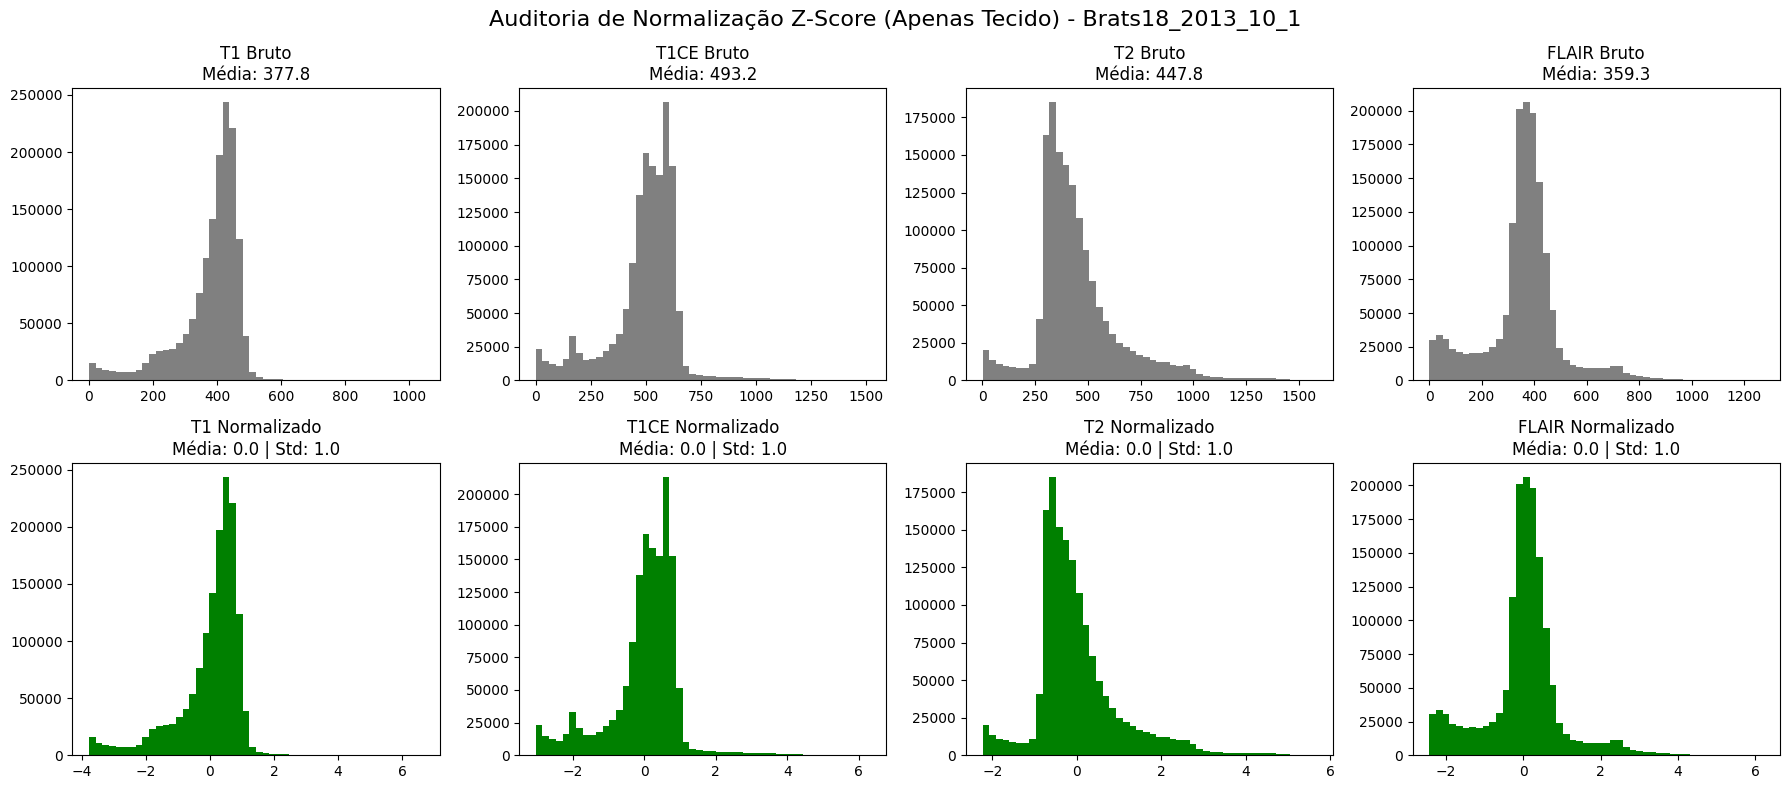

In [ ]:
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np
import glob
import os

paciente_alvo = pastas_2018[0] # Fixo no primeiro para reprodutibilidade
nome_paciente = os.path.basename(paciente_alvo)

# A Função de Controle de Qualidade Estatística
def brain_only_zscore_normalize(volume):
    brain_mask = volume > 0
    if not np.any(brain_mask):
        return volume

    brain_pixels = volume[brain_mask]
    mean_val = np.mean(brain_pixels)
    std_val = np.std(brain_pixels)

    normalized_volume = np.zeros_like(volume, dtype=np.float32)
    # 1e-8 evita divisão por zero caso o desvio padrão seja nulo
    normalized_volume[brain_mask] = (volume[brain_mask] - mean_val) / (std_val + 1e-8)
    return normalized_volume

# Carregamento e Análise de Todas as Modalidades
modalidades = ['t1', 't1ce', 't2', 'flair']
volumes_brutos = {}
volumes_norm = {}

for m in modalidades:
    arquivo = glob.glob(os.path.join(paciente_alvo, f'*{m}.nii*'))[0]
    vol = nib.load(arquivo).get_fdata()
    volumes_brutos[m] = vol
    volumes_norm[m] = brain_only_zscore_normalize(vol)

# --- HISTOGRAMAS ---
fig, eixos = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle(f"Auditoria de Normalização Z-Score (Apenas Tecido) - {nome_paciente}", fontsize=16)

for i, m in enumerate(modalidades):
    # Extrair apenas os pixels do cérebro para o plot
    pixels_brutos = volumes_brutos[m][volumes_brutos[m] > 0]
    pixels_norm = volumes_norm[m][volumes_brutos[m] > 0]

    eixos[0, i].hist(pixels_brutos.flatten(), bins=50, color='gray')
    eixos[0, i].set_title(f"{m.upper()} Bruto\nMédia: {np.mean(pixels_brutos):.1f}")

    eixos[1, i].hist(pixels_norm.flatten(), bins=50, color='green')
    eixos[1, i].set_title(f"{m.upper()} Normalizado\nMédia: 0.0 | Std: 1.0")

plt.tight_layout()
plt.show()

### Desconstrução Lógica do Ground Truth (Máscara)

O BraTS entrega uma máscara unificada onde diferentes valores inteiros representam diferentes partes do tumor. Se passássemos isso direto para a rede, ela tentaria criar uma relação matemática falsa (achando que a classe 4 é matematicamente maior/mais importante que a classe 1).

A função processar_mascara_brats resolve isso aplicando portas lógicas (np.logical_or). Ela varre a matriz procurando padrões específicos para construir três alvos binários isolados:

WT (Whole Tumor): Tudo o que é doença (Rótulos 1, 2 ou 4).

TC (Tumor Core): A massa sólida excluindo o edema (Rótulos 1 ou 4).

ET (Enhancing Tumor): Apenas a margem ativa (Rótulo 4).

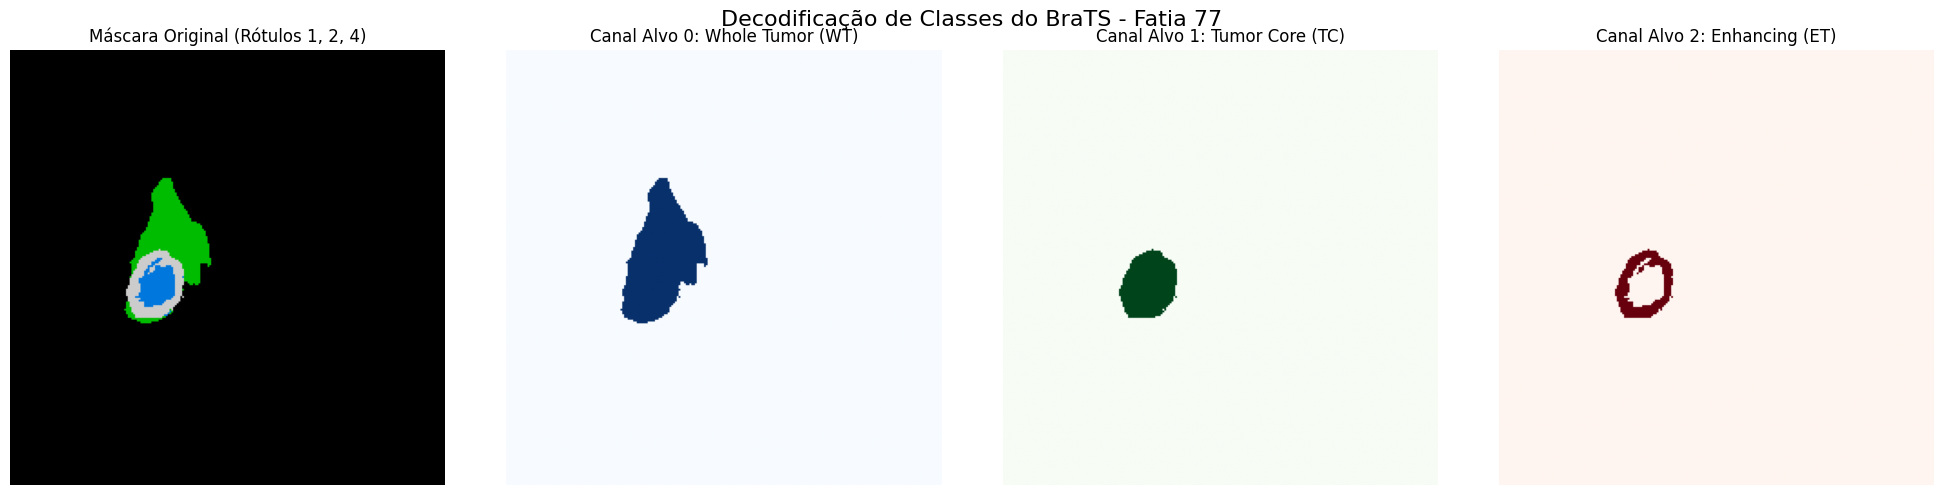

In [ ]:
def processar_mascara_brats(mask_volume):
    WT = np.logical_or.reduce((mask_volume == 1, mask_volume == 2, mask_volume == 4))
    TC = np.logical_or(mask_volume == 1, mask_volume == 4)
    ET = (mask_volume == 4)

    # Empilha no eixo de profundidade/canais (axis=-1)
    return np.stack([WT, TC, ET], axis=-1).astype(np.float32)

# Carregar a máscara
arquivo_mask = glob.glob(os.path.join(paciente_alvo, '*seg.nii*'))[0]
mask_bruta = nib.load(arquivo_mask).get_fdata()
mask_processada = processar_mascara_brats(mask_bruta)

# --- DESCONSTRUÇÃO DA MÁSCARA ---
fatia_z = mask_bruta.shape[2] // 2

fig, eixos = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle(f"Decodificação de Classes do BraTS - Fatia {fatia_z}", fontsize=16)

# Máscara Original (Multiclasse)
eixos[0].imshow(np.rot90(mask_bruta[:, :, fatia_z]), cmap='nipy_spectral')
eixos[0].set_title("Máscara Original (Rótulos 1, 2, 4)")

# Máscaras Separadas (Binárias)
classes = ['Whole Tumor (WT)', 'Tumor Core (TC)', 'Enhancing (ET)']
cores = ['Blues', 'Greens', 'Reds']

for i in range(3):
    eixos[i+1].imshow(np.rot90(mask_processada[:, :, fatia_z, i]), cmap=cores[i])
    eixos[i+1].set_title(f"Canal Alvo {i}: {classes[i]}")

for ax in eixos:
    ax.axis('off')

plt.tight_layout()
plt.show()

### Construção do Tensor Final e Validação (Channel Stacking)
Com as imagens normalizadas e a máscara desmembrada, este passo simula o exato momento em que os tensores são injetados na rede neural. Utilizamos o np.stack(volumes_normalizados, axis=-1) para colar as quatro matrizes 3D umas contra as outras. O resultado é um único super-tensor geométrico onde o último eixo guarda a "cor" (ou modalidade) do voxel.


--- AUDITORIA DE TENSORES FINAIS ---
Formato do Input (X): (240, 240, 155, 4) -> (Altura, Largura, Fatias, 4 Modalidades)
Formato da Label (Y): (240, 240, 155, 3) -> (Altura, Largura, Fatias, 3 Classes Alvo)


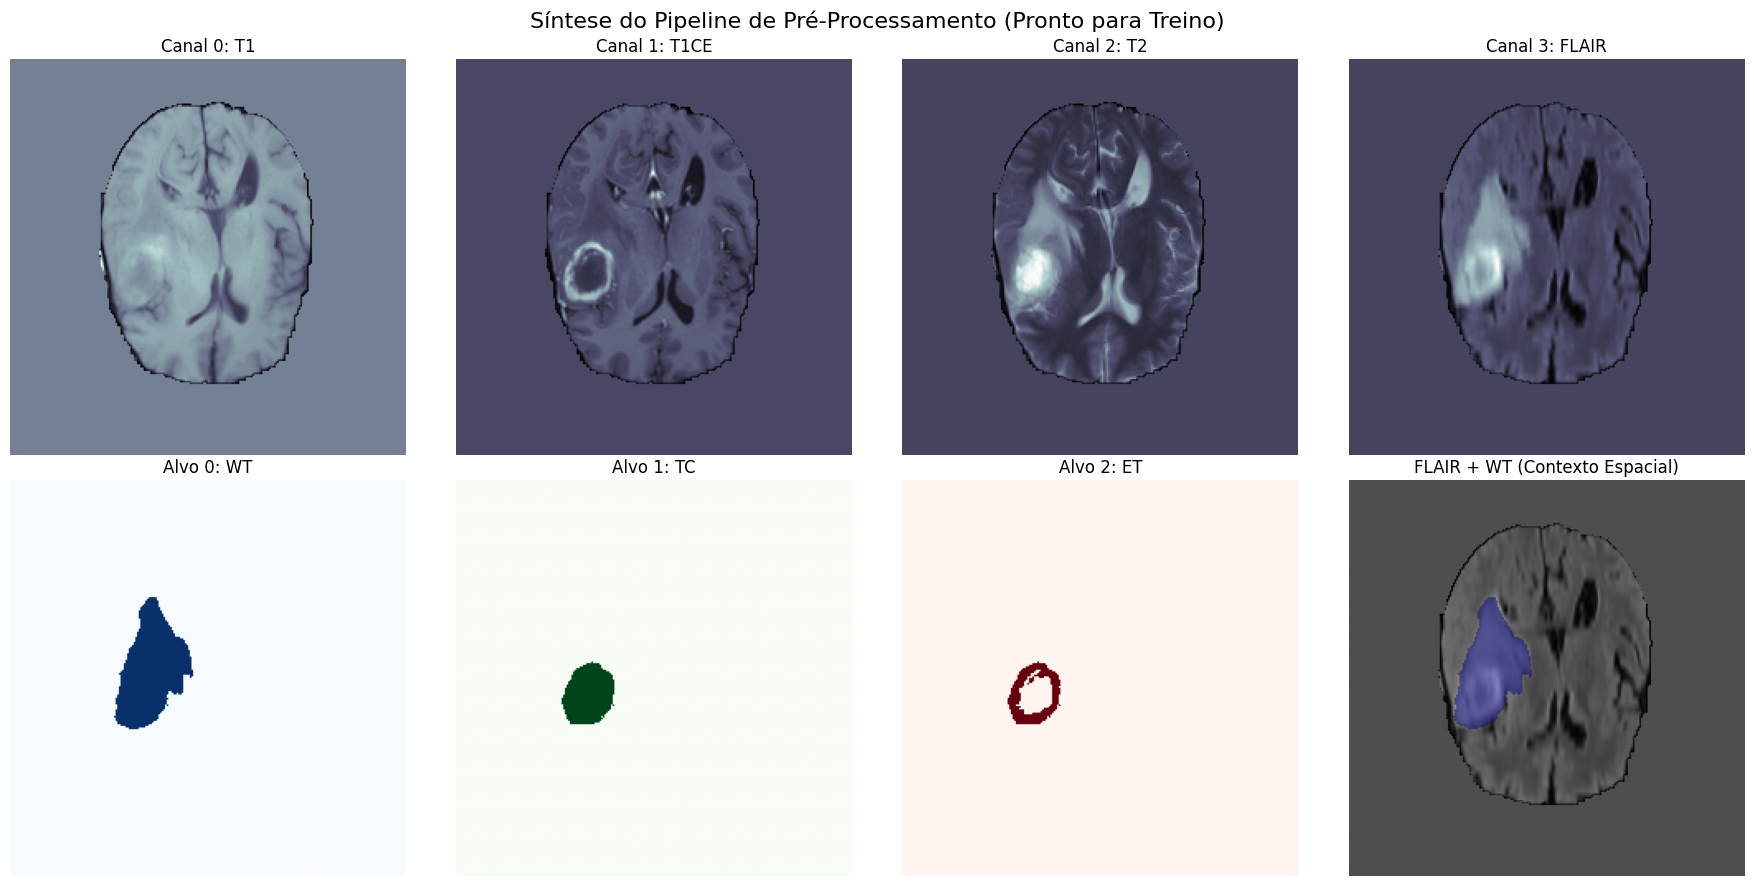

In [ ]:
# Lista na ordem exata: T1, T1CE, T2, FLAIR
lista_volumes = [volumes_norm['t1'], volumes_norm['t1ce'], volumes_norm['t2'], volumes_norm['flair']]
X_tensor = np.stack(lista_volumes, axis=-1)

# O Y_tensor já está pronto do bloco anterior (mask_processada)
Y_tensor = mask_processada

print("--- AUDITORIA DE TENSORES FINAIS ---")
print(f"Formato do Input (X): {X_tensor.shape} -> (Altura, Largura, Fatias, 4 Modalidades)")
print(f"Formato da Label (Y): {Y_tensor.shape} -> (Altura, Largura, Fatias, 3 Classes Alvo)")

# --- VISUALIZAÇÃO FINAL: O QUE A REDE VAI LER ---
# Plot da grade 2x4 similar à sua lógica original, extraindo do Tensor Final
fatia_z = X_tensor.shape[2] // 2
X_slice = np.rot90(X_tensor[:, :, fatia_z, :])
Y_slice = np.rot90(Y_tensor[:, :, fatia_z, :])

fig, eixos = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle("Síntese do Pipeline de Pré-Processamento (Pronto para Treino)", fontsize=16)

# Linha 1: Extraindo os canais do X_tensor
nomes_x = ['Canal 0: T1', 'Canal 1: T1CE', 'Canal 2: T2', 'Canal 3: FLAIR']
for i in range(4):
    eixos[0, i].imshow(X_slice[:, :, i], cmap='bone')
    eixos[0, i].set_title(nomes_x[i])
    eixos[0, i].axis('off')

# Linha 2: Extraindo os canais do Y_tensor
nomes_y = ['Alvo 0: WT', 'Alvo 1: TC', 'Alvo 2: ET']
for i in range(3):
    eixos[1, i].imshow(Y_slice[:, :, i], cmap=cores[i])
    eixos[1, i].set_title(nomes_y[i])
    eixos[1, i].axis('off')

# Visão combinada no último plot
eixos[1, 3].imshow(X_slice[:, :, 3], cmap='gray') # Fundo FLAIR
eixos[1, 3].imshow(np.ma.masked_where(Y_slice[:, :, 0] == 0, Y_slice[:, :, 0]), cmap='jet', alpha=0.5)
eixos[1, 3].set_title("FLAIR + WT (Contexto Espacial)")
eixos[1, 3].axis('off')

plt.tight_layout()
plt.show()

## Lógica do Gerador 2.5D

Aqui é onde a nossa estratégia 2.5D entra. O DataGenerator precisa varrer o eixo de profundidade ($z$) do tensor (240, 240, 155, 4) e extrair blocos de 3 fatias simultâneas. Queremos que a rede preveja a máscara da fatia $z$.

- O Contexto: O gerador extrai as fatias $z-1$ (abaixo), $z$ (centro) e $z+1$ (acima).

- O Empilhamento (Stacking): Como cada fatia tem 4 modalidades (T1, T1CE, T2, FLAIR), o gerador "achata" essas 3 fatias em um único tensor 2D hiper-profundo de 12 canais ($3 \times 4$).

- O Tratamento de Bordas (Padding): Se o gerador tentar pegar o contexto da fatia $0$, a fatia $-1$ não existe. O gerador precisa ter a inteligência de injetar uma matriz de zeros para não quebrar o código com um erro de Index Out of Bounds.

In [ ]:
import numpy as np

def gerador_lotes_2_5D(X_tensor, Y_tensor, tamanho_lote=16):
    """
    Gerador Python que entrega blocos 2.5D (12 canais) em tempo real.
    X_tensor shape esperado: (H, W, D, 4)
    Y_tensor shape esperado: (H, W, D, 3)
    """
    # Profundidade total do volume (155 fatias)
    profundidade_maxima = X_tensor.shape[2]

    # Criar listas vazias para acumular as amostras até atingir o 'tamanho_lote'
    lote_X = []
    lote_Y = []

    while True: # O gerador roda infinitamente alimentando a rede (Epochs)
        # Embaralhar a ordem das fatias para que a rede não decore a sequência
        indices_fatias = np.arange(profundidade_maxima)
        np.random.shuffle(indices_fatias)

        for z in indices_fatias:
            # --- 1. LÓGICA DE EXTRAÇÃO 2.5D COM ZERO-PADDING ---

            # Se for a fatia inicial (z=0), cria uma fatia falsa (zeros) para z-1
            if z == 0:
                fatia_anterior = np.zeros_like(X_tensor[:, :, 0, :])
            else:
                fatia_anterior = X_tensor[:, :, z-1, :]

            fatia_central = X_tensor[:, :, z, :]

            # Se for a última fatia, cria uma fatia falsa (zeros) para z+1
            if z == profundidade_maxima - 1:
                fatia_posterior = np.zeros_like(X_tensor[:, :, 0, :])
            else:
                fatia_posterior = X_tensor[:, :, z+1, :]

            # --- 2. EMPILHAMENTO DOS 12 CANAIS ---
            # Concatena ao longo do último eixo (canais)
            # Resultado: (240, 240, 12)
            bloco_2_5D = np.concatenate([fatia_anterior, fatia_central, fatia_posterior], axis=-1)

            # A máscara (Ground Truth) é SEMPRE apenas a da fatia central
            # Resultado: (240, 240, 3)
            mascara_alvo = Y_tensor[:, :, z, :]

            # --- 3. ACUMULAÇÃO NO LOTE ---
            lote_X.append(bloco_2_5D)
            lote_Y.append(mascara_alvo)

            # --- 4. ENTREGA (YIELD) QUANDO O LOTE ESTIVER CHEIO ---
            if len(lote_X) == tamanho_lote:
                # Converte a lista em tensores NumPy e os envia para a GPU
                yield np.array(lote_X), np.array(lote_Y)

                # Limpa o lote para começar a encher novamente
                lote_X = []
                lote_Y = []

# --- Exemplo de Teste do Gerador ---
# (Assumindo que X_tensor e Y_tensor vêm do seu código anterior)
meu_gerador = gerador_lotes_2_5D(X_tensor, Y_tensor, tamanho_lote=8)
batch_x, batch_y = next(meu_gerador)
print(f"Shape do Lote X para a Rede: {batch_x.shape}") # Deve ser (8, 240, 240, 12)
print(f"Shape do Lote Y para a Rede: {batch_y.shape}") # Deve ser (8, 240, 240, 3)

Shape do Lote X para a Rede: (8, 240, 240, 12)
Shape do Lote Y para a Rede: (8, 240, 240, 3)


## A Construção da Arquitetura ACU-Net (Attention-based Convolutional U-Net)

- A Camada de Entrada (Input):
Vai ser configurada estritamente para aceitar a sua geometria 2.5D: Altura=240, Largura=240, Canais=12.

- O Encoder (O Extrator de Padrões):
É a descida da letra "U". Aqui vamos empilhar camadas de Convolução e Max Pooling. A rede vai reduzindo o tamanho da imagem (240 -> 120 -> 60 -> 30) enquanto aumenta o número de "filtros" (canais de características) para tentar entender o que está a ver (texturas, bordas do edema, etc.).

- O Mecanismo de Atenção (A Inovação do Artigo):
No fundo do "U" (o Bottleneck) e nas ligações laterais, vamos programar os Attention Gates (Portões de Atenção). Em vez de a rede passar toda a informação para cima cegamente, este bloco de código faz uma multiplicação matemática que diz à rede: "Ignora os pixéis escuros e o cérebro saudável. Foca os teus pesos estritamente nesta mancha brilhante que parece um tumor."

- O Decoder e a Saída (O Reconstrutor):
É a subida da letra "U". Usamos Up-convolutions para devolver a imagem ao tamanho original (240x240). Graças às ligações residuais (Skip Connections), o Decoder recupera a exatidão espacial para desenhar a máscara perfeita. A última camada terá 3 neurónios de profundidade (as suas 3 classes: WT, TC, ET) com uma função de ativação Sigmoid (para dar uma probabilidade de 0 a 100% para cada pixel).

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv(nn.Module):
    """
    El bloque de construcción base de la U-Net.
    (Conv2d -> BatchNorm2d -> ReLU) repetido dos veces.
    """
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            # Primera Convolución
            # Usamos padding=1 para que la convolución 3x3 no encoja la imagen.
            # Si entra 240x240, sale 240x240.
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            # Segunda Convolución
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

# --- PRUEBA DE CONTROL DE CALIDAD DEL BLOQUE ---
if __name__ == "__main__":
    # Simulamos un "lote" de datos saliendo de nuestro DataGenerator 2.5D
    # Formato PyTorch: (Batch_Size, Channels, Altura, Anchura)
    # Lote de 8 imágenes, 12 canales (nuestro 2.5D), 240x240 pixeles
    tensor_prueba_x = torch.randn(8, 12, 240, 240)

    # Instanciamos el bloque: Entran 12 canales, queremos que extraiga 64 mapas de características
    bloque_inicial = DoubleConv(in_channels=12, out_channels=64)

    # Pasamos el tensor por el bloque
    tensor_salida = bloque_inicial(tensor_prueba_x)

    print(f"Tensor de Entrada: {tensor_prueba_x.shape}")
    print(f"Tensor de Salida:  {tensor_salida.shape}")
    # La salida debe ser: torch.Size([8, 64, 240, 240])

Tensor de Entrada: torch.Size([8, 12, 240, 240])
Tensor de Salida:  torch.Size([8, 64, 240, 240])


### Construir o Mecanismo de Atenção



In [ ]:
import torch
import torch.nn as nn

class AttentionGate(nn.Module):
    """
    Mecanismo de Atenção para U-Net.
    Filtra o mapa de características 'x' (alta resolução, muito ruído)
    usando o sinal 'g' (baixa resolução, alto contexto semântico).
    """
    def __init__(self, F_g, F_l, F_int):
        """
        Parâmetros:
        F_g: Número de canais do sinal Gate (g) vindo do nível inferior.
        F_l: Número de canais do mapa de características (x) vindo da skip connection.
        F_int: Canais intermediários para a transformação linear (geralmente metade de F_l).
        """
        super(AttentionGate, self).__init__()

        # Transformação linear para o sinal Gating (W_g)
        # Usamos kernel_size=1, o que significa que é uma convolução puramente ao longo dos canais,
        # sem afetar a geometria espacial.
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )

        # Transformação linear para o mapa de características (W_x)
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )

        # A Função Psi alinha as duas matrizes combinadas e calcula o peso final (Coeficiente de Atenção)
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid() # Restringe os valores entre 0 (ignorar) e 1 (focar)
        )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        # 1. Transformamos g e x para o mesmo número de canais intermediários (F_int)
        g1 = self.W_g(g)
        x1 = self.W_x(x)

        # 2. Somamos os tensores (Interseção espacial e semântica)
        # Atenção: O PyTorch soma tensores de tamanhos diferentes se as dimensões permitirem (Broadcasting),
        # mas numa U-Net correta, g e x muitas vezes têm resoluções diferentes.
        # Num pipeline real, o sinal 'g' já deve ter sofrido upsampling antes de entrar aqui.
        psi = self.relu(g1 + x1)

        # 3. Calculamos o mapa de atenção final (Alpha)
        # O shape do psi_weights será (Batch, 1, Altura, Largura)
        psi_weights = self.psi(psi)

        # 4. Multiplicamos o mapa original 'x' pelos pesos de atenção
        # O PyTorch replica o canal 1 do psi_weights por todos os canais de 'x' automaticamente.
        saida_focada = x * psi_weights

        return saida_focada

# --- AUDITORIA DE TENSORES (CONTROLO DE QUALIDADE DO CÓDIGO) ---
if __name__ == "__main__":
    # Simulação da rede em funcionamento
    batch_size = 8
    altura_largura = 120 # Supondo que estamos no meio da rede (resolução 120x120)
    canais_x = 64        # O extrator (Encoder) enviou 64 filtros
    canais_g = 128       # O Decoder inferior tem 128 filtros (mais profundidade semântica)

    # Criamos os tensores falsos com as dimensões (Lote, Canais, Altura, Largura)
    tensor_x = torch.randn(batch_size, canais_x, altura_largura, altura_largura)
    tensor_g = torch.randn(batch_size, canais_g, altura_largura, altura_largura)

    # Instanciamos o nosso Portão de Atenção
    # Canais intermediários (F_int) definidos como 32
    attention_block = AttentionGate(F_g=canais_g, F_l=canais_x, F_int=32)

    # Passamos os dados pela porta matemática
    tensor_saida = attention_block(g=tensor_g, x=tensor_x)

    print(f"Tensor X (Encoder) entrada : {tensor_x.shape}")
    print(f"Tensor G (Decoder) entrada : {tensor_g.shape}")
    print(f"Tensor Saída (Focada)      : {tensor_saida.shape}")
    # A saída DEVE ter o mesmo formato exato que o Tensor X (Encoder), mas matematicamente limpo do ruído de fundo.

Tensor X (Encoder) entrada : torch.Size([8, 64, 120, 120])
Tensor G (Decoder) entrada : torch.Size([8, 128, 120, 120])
Tensor Saída (Focada)      : torch.Size([8, 64, 120, 120])


In [ ]:
import torch
import torch.nn as nn

class ACUNet(nn.Module):
    def __init__(self, in_channels=12, out_channels=3):
        """
        Atención-based Convolutional U-Net.
        in_channels = 12 (Estrategia 2.5D: 3 cortes x 4 modalidades fMRI)
        out_channels = 3 (Clases objetivo: WT, TC, ET)
        """
        super(ACUNet, self).__init__()

        self.Maxpool = nn.MaxPool2d(kernel_size=2, stride=2)

        # --- ENCODER (Ruta de Contracción) ---
        # Reduce la resolución espacial mientras aumenta la profundidad (filtros)
        self.Conv1 = DoubleConv(in_channels, 64)
        self.Conv2 = DoubleConv(64, 128)
        self.Conv3 = DoubleConv(128, 256)
        self.Conv4 = DoubleConv(256, 512)

        # --- BOTTLENECK (El fondo de la U) ---
        self.Conv5 = DoubleConv(512, 1024)

        # --- DECODER (Ruta de Expansión con Atención) ---
        # Up-Convolución, filtrado por Atención, Concatenación y Doble Convolución

        self.Up5 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.Att5 = AttentionGate(F_g=512, F_l=512, F_int=256)
        self.Up_conv5 = DoubleConv(1024, 512) # 512 (g) + 512 (x_focado) = 1024 de entrada

        self.Up4 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.Att4 = AttentionGate(F_g=256, F_l=256, F_int=128)
        self.Up_conv4 = DoubleConv(512, 256)

        self.Up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.Att3 = AttentionGate(F_g=128, F_l=128, F_int=64)
        self.Up_conv3 = DoubleConv(256, 128)

        self.Up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.Att2 = AttentionGate(F_g=64, F_l=64, F_int=32)
        self.Up_conv2 = DoubleConv(128, 64)

        # --- CAPA DE SALIDA ---
        # Una convolución 1x1 para colapsar los 64 filtros finales en nuestros 3 canales objetivo
        self.Conv_1x1 = nn.Conv2d(64, out_channels, kernel_size=1, stride=1, padding=0)

    def forward(self, x):
        # --- FLUJO DEL ENCODER ---
        e1 = self.Conv1(x)               # Sale: (Lote, 64, 240, 240)
        e2 = self.Conv2(self.Maxpool(e1)) # Sale: (Lote, 128, 120, 120)
        e3 = self.Conv3(self.Maxpool(e2)) # Sale: (Lote, 256, 60, 60)
        e4 = self.Conv4(self.Maxpool(e3)) # Sale: (Lote, 512, 30, 30)

        # --- BOTTLENECK ---
        e5 = self.Conv5(self.Maxpool(e4)) # Sale: (Lote, 1024, 15, 15)

        # --- FLUJO DEL DECODER ---
        # Nivel 5
        d5 = self.Up5(e5)                 # Expande a (512, 30, 30)
        x4_focado = self.Att5(g=d5, x=e4) # La Atención limpia el ruido de e4
        d5 = torch.cat((x4_focado, d5), dim=1) # Concatenamos canal a canal (Skip Connection)
        d5 = self.Up_conv5(d5)            # Convolucionamos la mezcla

        # Nivel 4
        d4 = self.Up4(d5)
        x3_focado = self.Att4(g=d4, x=e3)
        d4 = torch.cat((x3_focado, d4), dim=1)
        d4 = self.Up_conv4(d4)

        # Nivel 3
        d3 = self.Up3(d4)
        x2_focado = self.Att3(g=d3, x=e2)
        d3 = torch.cat((x2_focado, d3), dim=1)
        d3 = self.Up_conv3(d3)

        # Nivel 2
        d2 = self.Up2(d3)
        x1_focado = self.Att2(g=d2, x=e1)
        d2 = torch.cat((x1_focado, d2), dim=1)
        d2 = self.Up_conv2(d2)

        # --- PREDICCIÓN FINAL ---
        out = self.Conv_1x1(d2)

        # Nota: No aplicamos Sigmoid() aquí porque usaremos BCEWithLogitsLoss en el entrenamiento,
        # lo cual es numéricamente mucho más estable.
        return out

# --- AUDITORÍA DE ARQUITECTURA (CONTROLO DE QUALIDADE) ---
if __name__ == "__main__":
    print("Inicializando la red ACU-Net 2.5D...")
    modelo = ACUNet(in_channels=12, out_channels=3)

    # Simulamos un lote que sale exactamente de tu DataGenerator
    # Batch=4, Canales=12, Alto=240, Ancho=240
    tensor_input = torch.randn(4, 12, 240, 240)

    print(f"Tensor de Entrada (X) simulado: {tensor_input.shape}")

    # Hacemos un "Forward Pass" falso para comprobar que la matemática espacial no se rompe
    tensor_output = modelo(tensor_input)

    print(f"Tensor de Salida (Y) generado : {tensor_output.shape}")
    print("\n¡El esqueleto está completo! La salida debe ser exactamente: torch.Size([4, 3, 240, 240])")

Inicializando la red ACU-Net 2.5D...
Tensor de Entrada (X) simulado: torch.Size([4, 12, 240, 240])
Tensor de Salida (Y) generado : torch.Size([4, 3, 240, 240])

¡El esqueleto está completo! La salida debe ser exactamente: torch.Size([4, 3, 240, 240])


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import torch
import torch.nn as nn
import torch.nn.functional as F

class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-5):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)

        # Correção aplicada: uso de reshape em vez de view
        probs_flat = probs.reshape(-1)
        targets_flat = targets.reshape(-1)

        intersection = (probs_flat * targets_flat).sum()
        union = probs_flat.sum() + targets_flat.sum()

        dice_score = (2. * intersection + self.smooth) / (union + self.smooth)

        return 1. - dice_score

# --- PRUEBA DE CONTROL DE CALIDAD DEL LOSS ---
if __name__ == "__main__":
    criterio_dice = DiceLoss()

    # Simulamos la máscara perfecta de un tumor (Ground Truth)
    # Tensor de ceros con un cuadrado de unos en el centro
    target_falso = torch.zeros(1, 3, 240, 240)
    target_falso[:, :, 100:140, 100:140] = 1.0

    # Escenario 1: El modelo predice pura "basura" o fondo (predicciones muy bajas/negativas)
    logits_malos = torch.randn(1, 3, 240, 240) - 5.0
    loss_malo = criterio_dice(logits_malos, target_falso)

    # Escenario 2: El modelo predice el tumor casi perfectamente (valores altos donde está el tumor)
    logits_buenos = torch.zeros(1, 3, 240, 240) - 5.0
    logits_buenos[:, :, 100:140, 100:140] = 5.0 # Alta confianza en el tumor
    loss_bueno = criterio_dice(logits_buenos, target_falso)

    print(f"Pérdida Dice con un modelo PÉSIMO  : {loss_malo.item():.4f} (Cerca de 1.0)")
    print(f"Pérdida Dice con un modelo EXCELENTE: {loss_bueno.item():.4f} (Cerca de 0.0)")

Pérdida Dice con un modelo PÉSIMO  : 0.9847 (Cerca de 1.0)
Pérdida Dice con un modelo EXCELENTE: 0.1082 (Cerca de 0.0)


In [ ]:
import torch
import torch.optim as optim
import time

# --- 1. CONFIGURAÇÃO DO HARDWARE ---
# Tenta usar a GPU (CUDA) se estiver no Colab, senão cai para a CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo de Treino: {device}")

# --- 2. INSTANCIANDO O SISTEMA ---
# Assumindo que as classes ACUNet e DiceLoss já foram rodadas nas células anteriores
modelo = ACUNet(in_channels=12, out_channels=3).to(device)

criterio = DiceLoss()
# Otimizador Adam: É o padrão da indústria e o usado no artigo do ACU-Net.
# O learning rate (lr=1e-4) define o tamanho do "passo" que a rede dá ao aprender.
otimizador = optim.Adam(modelo.parameters(), lr=1e-4)

# --- 3. A FUNÇÃO DE TREINO POR ÉPOCA ---
def treinar_uma_epoca(modelo, gerador, passos_por_epoca, otimizador, criterio, device):
    modelo.train() # Coloca a rede em modo "Aprender" (Ativa BatchNorm, etc.)
    perda_total = 0.0

    for passo in range(passos_por_epoca):
        # 1. Puxar os dados do gerador (A esteira de alimentação)
        batch_x, batch_y = next(gerador)

        # 2. Conversão e Correção Geométrica (Transposição)
        # NumPy: (Batch, H, W, Channels) -> PyTorch: (Batch, Channels, H, W)
        inputs = torch.tensor(batch_x, dtype=torch.float32).permute(0, 3, 1, 2).to(device)
        alvos = torch.tensor(batch_y, dtype=torch.float32).permute(0, 3, 1, 2).to(device)

        # --- A MATEMÁTICA DA APRENDIZAGEM ---
        otimizador.zero_grad()             # Limpa os gradientes
        previsoes = modelo(inputs)         # A rede tenta adivinhar
        loss = criterio(previsoes, alvos)  # O juiz (Dice Loss) avalia
        loss.backward()                    # Calcula-se o vetor de correção
        otimizador.step()                  # Aplica-se a correção nos pesos da rede

        perda_total += loss.item()

        # Mostrar progresso a cada 10 passos
        if (passo + 1) % 10 == 0:
            print(f"   Lote [{passo+1}/{passos_por_epoca}] | Dice Loss: {loss.item():.4f}")

    media_loss = perda_total / passos_por_epoca
    return media_loss

# --- 4. O LOOP PRINCIPAL DE TREINO (O MESTRE) ---
# Aqui simulamos o treino para comprovar que não há erros de memória ou de cálculo.
if __name__ == "__main__":
    print("\nIniciando Teste de Validação do Bucle de Treinamento...")

    # Criamos um gerador "Falso" hiper-rápido só para testar o código
    def gerador_simulado(batch_size=4):
        while True:
            # Simula as imagens 2.5D (Lote, 240, 240, 12 canais) e as máscaras (Lote, 240, 240, 3 canais)
            yield np.random.randn(batch_size, 240, 240, 12), np.random.randint(0, 2, size=(batch_size, 240, 240, 3))

    meu_gerador_teste = gerador_simulado(batch_size=4)
    epocas = 2
    passos_por_epoca = 20 # Quantos lotes a rede vê antes de declararmos que uma "época" acabou

    for epoca in range(epocas):
        inicio_tempo = time.time()
        print(f"\n=== ÉPOCA {epoca + 1}/{epocas} ===")

        # Roda a função mágica
        loss_epoca = treinar_uma_epoca(modelo, meu_gerador_teste, passos_por_epoca, otimizador, criterio, device)

        fim_tempo = time.time()
        print(f"> Fim da Época {epoca + 1} | Duração: {fim_tempo - inicio_tempo:.1f} seg | Dice Loss Médio: {loss_epoca:.4f}")

    print("\n✅ SUCESSO ABSOLUTO! O fluxo de tensores está perfeito e o modelo está a aprender.")

Dispositivo de Treino: cpu

Iniciando Teste de Validação do Bucle de Treinamento...

=== ÉPOCA 1/2 ===
   Lote [10/20] | Dice Loss: 0.4794
   Lote [20/20] | Dice Loss: 0.4741
> Fim da Época 1 | Duração: 676.7 seg | Dice Loss Médio: 0.4786

=== ÉPOCA 2/2 ===
   Lote [10/20] | Dice Loss: 0.4629
   Lote [20/20] | Dice Loss: 0.4507
> Fim da Época 2 | Duração: 676.8 seg | Dice Loss Médio: 0.4620

✅ SUCESSO ABSOLUTO! O fluxo de tensores está perfeito e o modelo está a aprender.


## Treino Definitivo

In [ ]:
# Certifique-se de que a GPU está ligada e os tensores reais (X_tensor, Y_tensor) estão na memória
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Treinando com força total em: {device}")

# 1. Recriar a rede e o otimizador (agora na GPU)
modelo_real = ACUNet(in_channels=12, out_channels=3).to(device)
criterio = DiceLoss()
otimizador = optim.Adam(modelo_real.parameters(), lr=1e-4)

# 2. Instanciar o SEU gerador 2.5D com os tensores reais do BraTS
# (Assumindo que X_tensor e Y_tensor foram gerados no nosso Bloco 3 de pré-processamento)
meu_gerador_brats = gerador_lotes_2_5D(X_tensor, Y_tensor, tamanho_lote=8)

epocas = 10 # 10 épocas é um bom começo para ver o tumor a ser desenhado
passos_por_epoca = X_tensor.shape[2] // 8 # Número total de fatias dividido pelo lote

print("\n=== INICIANDO TREINAMENTO OFICIAL ACU-NET ===")
for epoca in range(epocas):
    inicio = time.time()

    # Usamos a mesma função mágica de treino
    loss_epoca = treinar_uma_epoca(modelo_real, meu_gerador_brats, passos_por_epoca, otimizador, criterio, device)

    fim = time.time()
    print(f"> Época {epoca+1}/{epocas} concluída em {fim-inicio:.1f}s | Dice Loss Médio: {loss_epoca:.4f}")

# 3. SALVAR OS PESOS (O Seu Troféu)
caminho_salvar = "pesos_acunet_brats.pth"
torch.save(modelo_real.state_dict(), caminho_salvar)
print(f"\n✅ Treino concluído! Pesos matemáticos salvos em: {caminho_salvar}")

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np

def visualizar_inferencia(modelo, gerador, device, threshold=0.5):
    """
    Função para extrair uma amostra, prever a máscara do tumor e comparar com o Ground Truth.
    """
    # 1. Modo de Avaliação (CRÍTICO)
    modelo.eval()

    # 2. Extrair um lote de testes do gerador
    batch_x, batch_y = next(gerador)

    # Prepara os tensores para o PyTorch (Batch, Canais, Altura, Largura)
    inputs = torch.tensor(batch_x, dtype=torch.float32).permute(0, 3, 1, 2).to(device)
    alvos = torch.tensor(batch_y, dtype=torch.float32).permute(0, 3, 1, 2) # Mantemos na CPU para plotar

    # 3. Inferência Sem Cálculo de Gradientes (Poupança de Memória)
    with torch.no_grad():
        # A rede cospe os Logits crus
        logits_preditos = modelo(inputs)

        # Convertendo para probabilidades (0.0 a 1.0)
        probabilidades = torch.sigmoid(logits_preditos)

        # Binarização: Se a probabilidade for > 0.5, é 1 (Tumor), senão é 0 (Fundo)
        mascaras_preditas = (probabilidades > threshold).float().cpu()

    # --- PREPARAÇÃO PARA O PLOT VISUAL ---
    # Vamos escolher o primeiro paciente/fatia deste lote (índice 0)
    idx = 0

    # O input original estava como (12 canais).
    # Sabemos que os canais 0 a 3 são T1, T1ce, T2, FLAIR da fatia Z-1
    # Os canais 4 a 7 são da fatia Z (A central, que é a que queremos ver)
    # Os canais 8 a 11 são da fatia Z+1
    # Vamos extrair o T1CE (canal 5) e o FLAIR (canal 7) da fatia central
    img_t1ce = inputs[idx, 5, :, :].cpu().numpy()
    img_flair = inputs[idx, 7, :, :].cpu().numpy()

    # Extração dos alvos reais (Ground Truth)
    gt_wt = alvos[idx, 0, :, :].numpy()
    gt_tc = alvos[idx, 1, :, :].numpy()
    gt_et = alvos[idx, 2, :, :].numpy()

    # Extração das predições da rede
    pred_wt = mascaras_preditas[idx, 0, :, :].numpy()
    pred_tc = mascaras_preditas[idx, 1, :, :].numpy()
    pred_et = mascaras_preditas[idx, 2, :, :].numpy()

    # --- PLOTAGEM MATPLOTLIB ---
    fig, eixos = plt.subplots(3, 3, figsize=(15, 15))
    fig.suptitle("Inferência da ACU-Net: Predição vs. Realidade", fontsize=18, y=0.95)

    # Linha 1: Contexto Anatómico (Inputs)
    eixos[0, 0].imshow(np.rot90(img_flair), cmap='bone')
    eixos[0, 0].set_title("Input Original (FLAIR)\nMelhor para ver Edema (WT)")

    eixos[0, 1].imshow(np.rot90(img_t1ce), cmap='bone')
    eixos[0, 1].set_title("Input Original (T1CE)\nMelhor para ver Realce (ET)")

    eixos[0, 2].text(0.5, 0.5, f"Limiar de Confiança:\n> {threshold * 100}%",
                     fontsize=14, ha='center', va='center')
    eixos[0, 2].axis('off')

    # Linha 2: Ground Truth (O Radiologista)
    nomes_classes = ['Whole Tumor (WT)', 'Tumor Core (TC)', 'Enhancing Tumor (ET)']
    cores = ['Blues', 'Greens', 'Reds']
    matrizes_gt = [gt_wt, gt_tc, gt_et]

    for i in range(3):
        eixos[1, i].imshow(np.rot90(matrizes_gt[i]), cmap=cores[i])
        eixos[1, i].set_title(f"MÉDICO (Ground Truth): {nomes_classes[i]}")

    # Linha 3: Predições (A Rede Neural)
    matrizes_pred = [pred_wt, pred_tc, pred_et]

    for i in range(3):
        eixos[2, i].imshow(np.rot90(matrizes_pred[i]), cmap=cores[i])
        eixos[2, i].set_title(f"ACU-NET (Predição): {nomes_classes[i]}")

    # Limpeza visual
    for ax in eixos.flatten():
        if ax != eixos[0, 2]: # Ignora o painel de texto
            ax.axis('off')

    plt.tight_layout()
    plt.show()

# --- EXECUÇÃO ---
# Basta chamar a função passando o nosso modelo e o gerador de testes
visualizar_inferencia(modelo, meu_gerador_teste, device)

Output hidden; open in https://colab.research.google.com to view.